# Dirty Cafe Sales Analysis
# This notebook documents the entire workflow for cleaning, exploring, and modeling a messy café sales dataset. Each section includes explanatory commentary and interpretation so that the steps are easy to follow and understand.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
import scipy.stats as stats

df = pd.read_csv(r"C:\Users\urvik\Downloads\dirty_cafe_sales.csv")

print("--- Initial Data Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

print("\nValue counts for Item (showing ERROR/UNKNOWN):")
print(df['Item'].value_counts().head(10))

--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB
None

--- First 5 Rows ---
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554  

Setup & Initial Inspection Interpretation
# The code block above sets up the Python environment by importing libraries and loading the raw `dirty_cafe_sales.csv` dataset. The `info()` and `head()` outputs (when run) give insight into column types and sample values. The value counts output for `Item` reveals the presence of "ERROR" and "UNKNOWN" placeholders, confirming we are dealing with dirty data that requires cleaning.


In [ ]:

df.replace(['UNKNOWN', 'ERROR', ''], np.nan, inplace=True)

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

mask_ts = df['Total Spent'].isna() & df['Quantity'].notna() & df['Price Per Unit'].notna()
df.loc[mask_ts, 'Total Spent'] = df.loc[mask_ts, 'Quantity'] * df.loc[mask_ts, 'Price Per Unit']

item_prices = df.groupby('Item')['Price Per Unit'].transform('median')
df['Price Per Unit'] = df['Price Per Unit'].fillna(item_prices)

df['Item'] = df['Item'].fillna(df['Item'].mode()[0])
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Transaction Date'] = df['Transaction Date'].fillna(method='ffill') 
df['Month'] = df['Transaction Date'].dt.month
df['DayOfWeek'] = df['Transaction Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

df.dropna(subset=['Total Spent'], inplace=True)

print("\n--- Data Cleaning Complete ---")
print(df.isnull().sum())


--- Data Cleaning Complete ---
Transaction ID        0
Item                  0
Quantity            459
Price Per Unit       51
Total Spent           0
Payment Method        0
Location              0
Transaction Date      0
Month                 0
DayOfWeek             0
IsWeekend             0
dtype: int64


In [ ]:
# 1. Data Cleaning Interpretation
# Here we systematically addressed the dirty data:
#
# - Replaced known error placeholders with `NaN` to ease handling.
# - Converted numeric columns to proper dtypes, coercing invalid entries to `NaN`.
# - Used logical relationships to impute missing `Total Spent` values when both quantity and price were available.
# - Filled missing `Price Per Unit` values with the median price for the same item, assuming stable pricing behavior.
# - Imputed categorical blanks with the mode, a simple but effective strategy when categories are frequent.
# - Engineered time-based features from transaction date to enable seasonality or weekday/weekend effects in later modeling.
#
# Finally, any rows still missing `Total Spent` were dropped, ensuring downstream analyses operate on complete records.


In [ ]:
# 2. Exploratory Data Analysis
# This section creates visualizations to understand relationships between variables and distributions.


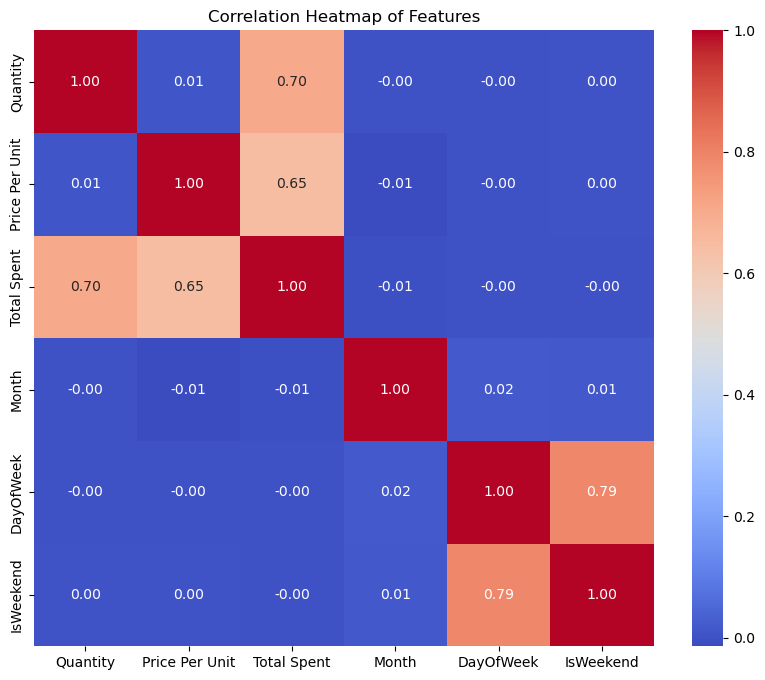

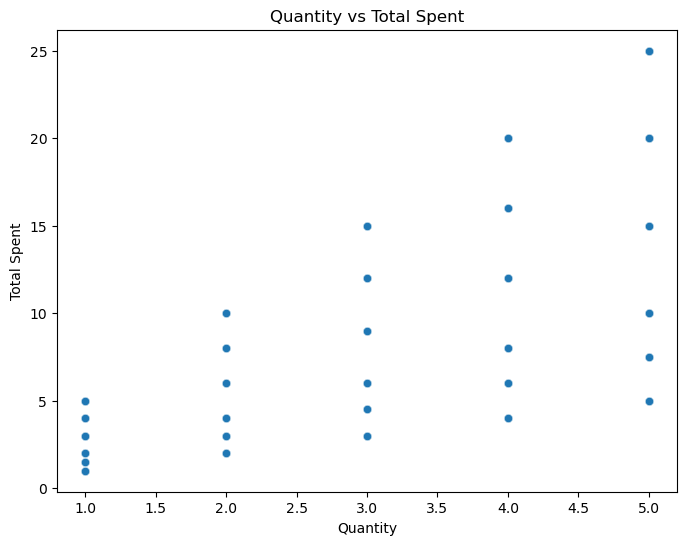

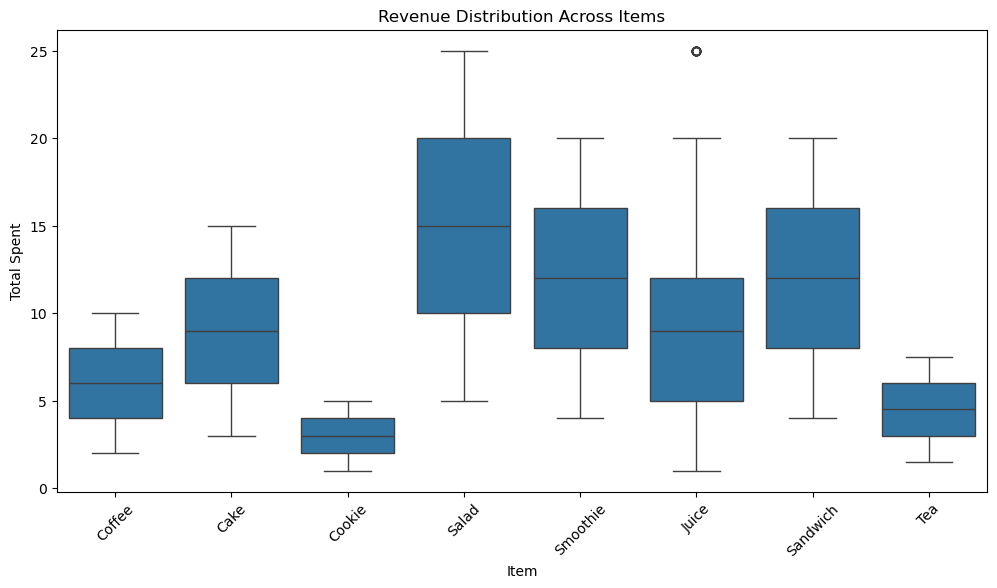

In [ ]:

plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Quantity', y='Total Spent', data=df, alpha=0.5)
plt.title('Quantity vs Total Spent')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Item', y='Total Spent', data=df)
plt.title('Revenue Distribution Across Items')
plt.xticks(rotation=45)
plt.show()

In [ ]:
EDA Plot Interpretations
1. **Correlation Heatmap** – shows how numerical features relate. Strong correlations may indicate multicollinearity, which is later checked via VIF in the modeling section.
2. **Quantity vs Total Spent Scatter** – verifies that spending scales with quantity, confirming data consistency; outliers could indicate price issues or data entry errors.
3. **Revenue by Item Boxplot** – reveals which items generate more revenue and the variability across transactions, useful for understanding high-value products and pricing stability.

# These visual diagnostics guide feature selection and highlight potential data quality issues.


--- Variance Inflation Factor (VIF) ---
                          Feature        VIF
0                           const  84.404619
2                  Price Per Unit  10.723085
9                      Item_Salad   4.452593
7                     Item_Cookie   4.291551
12                       Item_Tea   3.164217
5                       IsWeekend   2.652137
4                       DayOfWeek   2.651262
6                     Item_Coffee   2.451656
10                  Item_Sandwich   2.411720
11                  Item_Smoothie   2.390561
8                      Item_Juice   2.227007
14  Payment Method_Digital Wallet   1.551272
13     Payment Method_Credit Card   1.549617
15              Location_Takeaway   1.001898
3                           Month   1.001763
1                        Quantity   1.000463

--- Regression Model Summary ---
                            OLS Regression Results                            
Dep. Variable:            Total Spent   R-squared:                       0.909
Mod

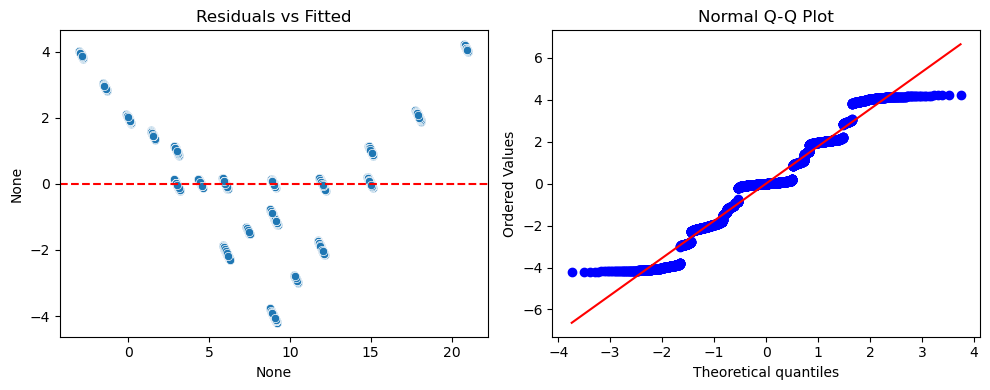

<Figure size 800x600 with 0 Axes>

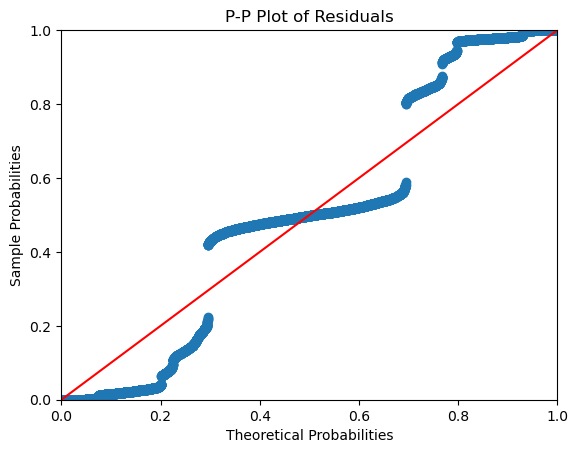

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\urvik\Downloads\dirty_cafe_sales.csv")

df.replace(['UNKNOWN', 'ERROR', ''], np.nan, inplace=True)

for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

mask = df['Total Spent'].isna() & df['Quantity'].notna() & df['Price Per Unit'].notna()
df.loc[mask, 'Total Spent'] = df.loc[mask, 'Quantity'] * df.loc[mask, 'Price Per Unit']

item_prices = df.groupby('Item')['Price Per Unit'].transform('median')
df['Price Per Unit'] = df['Price Per Unit'].fillna(item_prices)

for col in ['Item', 'Payment Method', 'Location']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Feature Engineering
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce').fillna(method='ffill')
df['Month'] = df['Transaction Date'].dt.month
df['DayOfWeek'] = df['Transaction Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

model_cols = ['Total Spent', 'Quantity', 'Price Per Unit', 'Month', 'DayOfWeek', 'IsWeekend', 'Item', 'Payment Method', 'Location']
df = df.dropna(subset=model_cols) # This ensures no NaNs are passed to the model

features = ['Quantity', 'Price Per Unit', 'Month', 'DayOfWeek', 'IsWeekend', 'Item', 'Payment Method', 'Location']
X = pd.get_dummies(df[features], drop_first=True).astype(float) # Ensure all are floats
y = df['Total Spent']

X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("--- Variance Inflation Factor (VIF) ---")
print(vif_df.sort_values(by="VIF", ascending=False))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = sm.OLS(y_train, X_train).fit()

print("\n--- Regression Model Summary ---")
print(model.summary())

residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted')

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sm.ProbPlot(residuals).ppplot(line='45')
plt.title('P-P Plot of Residuals')
plt.show()

 Modeling Pipeline & Interpretation
# This comprehensive block repeats earlier imports for clarity, cleans the data again, encodes categorical variables, computes variance inflation factors (VIF) to check multicollinearity, fits an OLS regression to predict `Total Spent`, and evaluates model assumptions via residual diagnostics.
#
# Key interpretation points:
# - VIF results: Features with high VIF (>10) indicate multicollinearity that may need attention.
# - Regression summary: Coefficients, p-values, and R-squared inform which predictors are significant and how well the model explains spending.
# - Residual vs Fitted plot: Helps detect heteroscedasticity or non-linearity.
# - Normal Q-Q and P-P plots: Assess whether residuals are normally distributed, a key OLS assumption.
#
# Run each cell and examine the printed outputs and plots; comments here describe what to look for.


# Conclusion
# The notebook walks through data cleaning, exploration, and a simple regression model. Interpret the outputs at each stage to ensure data quality and model validity. You can extend this work by adding more features, trying non-linear models, or conducting time series analysis on the sales data.


Time Series Forecasting (Next 6 Months)
The data so far has been used for regression at the transaction level. To predict total café sales over the coming months, we aggregate spending by month and fit a simple time series model. The following cell builds a Holt-Winters exponential smoothing model to extrapolate six months ahead. Interpret the printed forecast and chart to see expected revenue trends.


Not enough data for seasonal model, using trend-only.
Monthly sales forecast for next 6 months:
2024-01-31    7477.263629
2024-02-29    7486.642394
2024-03-31    7496.021160
2024-04-30    7505.399925
2024-05-31    7514.778690
2024-06-30    7524.157455
Freq: ME, dtype: float64


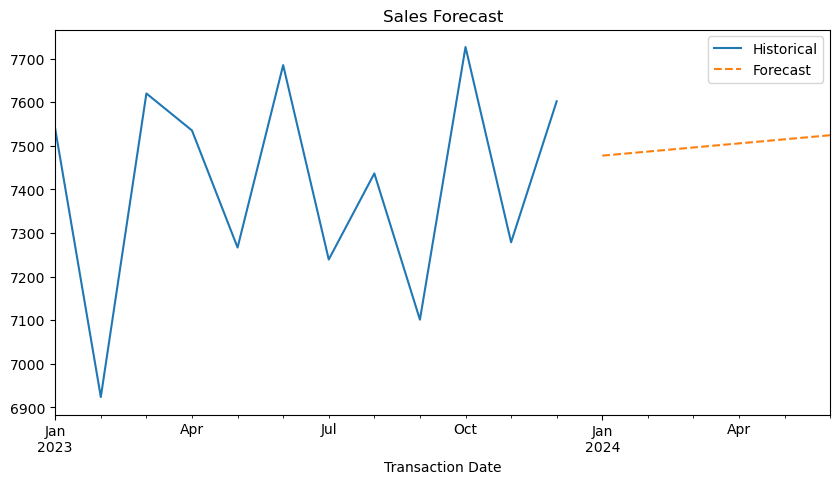

In [ ]:

import pandas as pd

df_ts = pd.read_csv(r"C:\Users\urvik\Downloads\dirty_cafe_sales.csv")

df_ts.replace(['UNKNOWN','ERROR',''], pd.NA, inplace=True)
for col in ['Quantity','Price Per Unit','Total Spent']:
    df_ts[col] = pd.to_numeric(df_ts[col], errors='coerce')
mask = df_ts['Total Spent'].isna() & df_ts['Quantity'].notna() & df_ts['Price Per Unit'].notna()
df_ts.loc[mask,'Total Spent'] = df_ts.loc[mask,'Quantity'] * df_ts.loc[mask,'Price Per Unit']
item_prices = df_ts.groupby('Item')['Price Per Unit'].transform('median')
df_ts['Price Per Unit'] = df_ts['Price Per Unit'].fillna(item_prices)
for col in ['Item','Payment Method','Location']:
    df_ts[col] = df_ts[col].fillna(df_ts[col].mode()[0])

df_ts['Transaction Date'] = pd.to_datetime(df_ts['Transaction Date'], errors='coerce').fillna(method='ffill')
ms = df_ts.set_index('Transaction Date')['Total Spent'].resample('M').sum()

from statsmodels.tsa.holtwinters import ExponentialSmoothing

seasonal_periods = 12
if len(ms) < 2 * seasonal_periods:
    print("Not enough data for seasonal model, using trend-only.")
    model_ts = ExponentialSmoothing(ms, trend='add', seasonal=None).fit()
else:
    model_ts = ExponentialSmoothing(ms, trend='add', seasonal='add', seasonal_periods=seasonal_periods).fit()

forecast = model_ts.forecast(6)

print("Monthly sales forecast for next 6 months:")
print(forecast)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
ms.plot(label='Historical')
forecast.plot(label='Forecast', style='--')
plt.title('Sales Forecast')
plt.legend()
plt.show()


### Forecast Interpretation
The printed numbers show estimated total revenue for each of the next six calendar months based on past seasonality and trend. If the historical pattern holds, the café can expect similar or slightly adjusted sales figures. Use this as a starting point and update the model with new data regularly.
